In [1]:
import cv2, os


video_path = "sample.mp4"  

os.makedirs("frames", exist_ok=True)


if not os.path.exists(video_path):
    print(f"Error: Video file '{video_path}' not found")
    print(f"Current directory: {os.getcwd()}")
    print(f"vailable files: {os.listdir('.')[:10]}")  
else:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Cannot open video file '{video_path}'")
    else:
        i = 0
        while i < 30:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.resize(frame, (256, 256))
            cv2.imwrite(f"frames/frame_{i:03d}.png", frame)
            i += 1
        cap.release()
        print(f"Extracted {i} frames from '{video_path}'")

Extracted 30 frames from 'sample.mp4'


In [2]:

frames_dir = "frames"
output_bin = "output.bin"
GOP_SIZE   = 4
SEARCH_WIN = 8
Q_FACTOR   = 10


In [3]:
import numpy as np
Q_MATRIX = np.array([
    [16,11,10,16,24,40,51,61],
    [12,12,14,19,26,58,60,55],
    [14,13,16,24,40,57,69,56],
    [14,17,22,29,51,87,80,62],
    [18,22,37,56,68,109,103,77],
    [24,35,55,64,81,104,113,92],
    [49,64,78,87,103,121,120,101],
    [72,92,95,98,112,100,103,99]
], dtype=np.float32) * (Q_FACTOR / 10)

print("config ready | GOP:", GOP_SIZE, "| Q_FACTOR:", Q_FACTOR)

config ready | GOP: 4 | Q_FACTOR: 10


In [4]:
import numpy as np

def load_frames(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.png','.jpg'))])
    frames = [cv2.imread(os.path.join(folder, f)) for f in files]
    print(f"loaded {len(frames)} frames — size: {frames[0].shape}")
    return frames

def bgr_to_ycbcr(frame):

    yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    Y  = yuv[:, :, 0].astype(np.float32)
    Cb = yuv[:, :, 2].astype(np.float32)
    Cr = yuv[:, :, 1].astype(np.float32)

    Cb_sub = Cb[::2, ::2]
    Cr_sub = Cr[::2, ::2]
    return Y, Cb_sub, Cr_sub

def ycbcr_to_bgr(Y, Cb_sub, Cr_sub):

    h, w = Y.shape
    Cb = cv2.resize(Cb_sub, (w, h), interpolation=cv2.INTER_LINEAR)
    Cr = cv2.resize(Cr_sub, (w, h), interpolation=cv2.INTER_LINEAR)
    yuv = np.stack([Y, Cr, Cb], axis=2).clip(0, 255).astype(np.uint8)
    return cv2.cvtColor(yuv, cv2.COLOR_YCrCb2BGR)

raw_frames = load_frames(frames_dir)


loaded 30 frames — size: (256, 256, 3)


In [5]:
from scipy.fftpack import dctn, idctn

def dct2(block):
    return dctn(block, norm='ortho')

def idct2(block):
    return idctn(block, norm='ortho')

def quantise(dct_block, q_matrix):
    return np.round(dct_block / q_matrix).astype(np.int16)

def dequantise(q_block, q_matrix):
    return (q_block * q_matrix).astype(np.float32)

In [6]:
def encode_channel(channel, q_matrix):

    h, w = channel.shape
    ph = (8 - h % 8) % 8
    pw = (8 - w % 8) % 8
    padded = np.pad(channel, ((0, ph), (0, pw)), mode='edge')
    H, W = padded.shape
    blocks = []
    for r in range(0, H, 8):
        row_blocks = []
        for c in range(0, W, 8):
            block = padded[r:r+8, c:c+8] - 128.0
            dct_block = dct2(block)
            q_block   = quantise(dct_block, q_matrix)
            row_blocks.append(q_block)
        blocks.append(row_blocks)
    return blocks, (h, w)

def decode_channel(blocks, orig_shape, q_matrix):

    h, w = orig_shape
    ph = (8 - h % 8) % 8
    pw = (8 - w % 8) % 8
    H, W = h + ph, w + pw
    output = np.zeros((H, W), dtype=np.float32)
    for ri, row_blocks in enumerate(blocks):
        for ci, q_block in enumerate(row_blocks):
            deq   = dequantise(q_block, q_matrix)
            recon = idct2(deq)
            output[ri*8:(ri+1)*8, ci*8:(ci+1)*8] = recon
    return output[:h, :w].clip(0, 255)



In [7]:
def encode_iframe(frame, q_matrix):
    Y, Cb, Cr = bgr_to_ycbcr(frame)
    Y_blocks,  Y_shape  = encode_channel(Y,  q_matrix)
    Cb_blocks, Cb_shape = encode_channel(Cb, q_matrix)
    Cr_blocks, Cr_shape = encode_channel(Cr, q_matrix)
    return {'type': 'I', 'Y': Y_blocks, 'Cb': Cb_blocks, 'Cr': Cr_blocks,
            'Y_shape': Y_shape, 'Cb_shape': Cb_shape, 'Cr_shape': Cr_shape}

def decode_iframe(data, q_matrix):
    Y  = decode_channel(data['Y'],  data['Y_shape'],  q_matrix)
    Cb = decode_channel(data['Cb'], data['Cb_shape'], q_matrix)
    Cr = decode_channel(data['Cr'], data['Cr_shape'], q_matrix)
    return ycbcr_to_bgr(Y, Cb, Cr)



In [8]:
def motion_search(curr_block, ref_frame, ref_r, ref_c, mb_size, search_win):

    h, w = ref_frame.shape
    best_sad = float('inf')
    best_mv  = (0, 0)
    for dr in range(-search_win, search_win + 1):
        for dc in range(-search_win, search_win + 1):
            rr = ref_r + dr
            rc = ref_c + dc
            if rr < 0 or rc < 0 or rr + mb_size > h or rc + mb_size > w:
                continue
            ref_block = ref_frame[rr:rr+mb_size, rc:rc+mb_size]
            sad = np.sum(np.abs(curr_block.astype(np.float32) -
                                ref_block.astype(np.float32)))
            if sad < best_sad:
                best_sad = sad
                best_mv  = (dr, dc)
    return best_mv

def encode_pframe(frame, ref_recon, q_matrix, mb_size=16, search_win=8):
    Y, Cb, Cr = bgr_to_ycbcr(frame)
    ref_Y, _, _ = bgr_to_ycbcr(ref_recon)
    h, w = Y.shape
    mvs, res_blocks = [], []
    residual_map = np.zeros_like(Y)

    for r in range(0, h - mb_size + 1, mb_size):
        for c in range(0, w - mb_size + 1, mb_size):
            curr_block = Y[r:r+mb_size, c:c+mb_size]
            mv = motion_search(curr_block, ref_Y, r, c, mb_size, search_win)
            mvs.append((r, c, mv[0], mv[1]))
            pred_block = ref_Y[r+mv[0]:r+mv[0]+mb_size, c+mv[1]:c+mv[1]+mb_size]
            residual   = curr_block.astype(np.float32) - pred_block.astype(np.float32)
            residual_map[r:r+mb_size, c:c+mb_size] = residual

            blocks_res, shape_res = encode_channel(residual, q_matrix)
            res_blocks.append((r, c, blocks_res, shape_res))


    Cb_blocks, Cb_shape = encode_channel(Cb, q_matrix)
    Cr_blocks, Cr_shape = encode_channel(Cr, q_matrix)
    return {'type': 'P', 'mvs': mvs, 'res_blocks': res_blocks,
            'Cb': Cb_blocks, 'Cr': Cr_blocks,
            'Cb_shape': Cb_shape, 'Cr_shape': Cr_shape,
            'Y_shape': (h, w), 'residual_map': residual_map}

def decode_pframe(data, ref_recon, q_matrix, mb_size=16):
    ref_Y, _, _ = bgr_to_ycbcr(ref_recon)
    h, w = data['Y_shape']
    Y_recon = np.zeros((h, w), dtype=np.float32)

    for (r, c, blocks_res, shape_res) in data['res_blocks']:

        mv = next((mv for (mr, mc, dr, dc) in data['mvs']
                   if mr == r and mc == c for mv in [(dr, dc)]), (0, 0))
        pred_block = ref_Y[r+mv[0]:r+mv[0]+mb_size, c+mv[1]:c+mv[1]+mb_size]
        res_recon  = decode_channel(blocks_res, shape_res, q_matrix)
        Y_recon[r:r+mb_size, c:c+mb_size] = (pred_block + res_recon).clip(0, 255)

    Cb = decode_channel(data['Cb'], data['Cb_shape'], q_matrix)
    Cr = decode_channel(data['Cr'], data['Cr_shape'], q_matrix)
    return ycbcr_to_bgr(Y_recon, Cb, Cr)



In [9]:
import pickle, zlib

def encode_video(frames, output_path, q_matrix, gop=4, search_win=8):
    encoded_frames = []
    recon_frames   = []

    for i, frame in enumerate(frames):
        if i % gop == 0:
            data  = encode_iframe(frame, q_matrix)
            recon = decode_iframe(data, q_matrix)
            print(f"  Frame {i:03d} → I-frame")
        else:
            ref   = recon_frames[-1]
            data  = encode_pframe(frame, ref, q_matrix, search_win=search_win)
            recon = decode_pframe(data, ref, q_matrix)
            
            data_clean = {k: v for k, v in data.items() if k != 'residual_map'}
            data = data_clean
            print(f"  Frame {i:03d} → P-frame")
        encoded_frames.append(data)
        recon_frames.append(recon)


    raw   = pickle.dumps(encoded_frames)
    compressed = zlib.compress(raw, level=9)
    with open(output_path, 'wb') as f:
        f.write(compressed)

    orig_size = sum(f.size * f.itemsize if hasattr(f,'size')
                    else np.prod(f.shape)*3 for f in frames)
    orig_bytes = frames[0].shape[0] * frames[0].shape[1] * 3 * len(frames)
    ratio = orig_bytes / len(compressed)
    print(f"\n Encoded {len(frames)} frames → {output_path}")
    print(f"   Original : {orig_bytes:,} bytes")
    print(f"   Compressed: {len(compressed):,} bytes")
    print(f"   Compression ratio: {ratio:.2f}x")
    return recon_frames, ratio

def decode_video(input_path, q_matrix):
    with open(input_path, 'rb') as f:
        compressed = f.read()
    raw = zlib.decompress(compressed)
    encoded_frames = pickle.loads(raw)

    recon_frames = []
    for i, data in enumerate(encoded_frames):
        if data['type'] == 'I':
            recon = decode_iframe(data, q_matrix)
        else:
            recon = decode_pframe(data, recon_frames[-1], q_matrix)
        recon_frames.append(recon)
    print(f"Decoded {len(recon_frames)} frames from {input_path}")
    return recon_frames


print("Encoding video...")
recon_frames, comp_ratio = encode_video(
    raw_frames, output_bin, Q_MATRIX, gop=GOP_SIZE, search_win=SEARCH_WIN
)

Encoding video...
  Frame 000 → I-frame
  Frame 001 → P-frame
  Frame 002 → P-frame
  Frame 003 → P-frame
  Frame 004 → I-frame
  Frame 005 → P-frame
  Frame 006 → P-frame
  Frame 007 → P-frame
  Frame 008 → I-frame
  Frame 009 → P-frame
  Frame 010 → P-frame
  Frame 011 → P-frame
  Frame 012 → I-frame
  Frame 013 → P-frame
  Frame 014 → P-frame
  Frame 015 → P-frame
  Frame 016 → I-frame
  Frame 017 → P-frame
  Frame 018 → P-frame
  Frame 019 → P-frame
  Frame 020 → I-frame
  Frame 021 → P-frame
  Frame 022 → P-frame
  Frame 023 → P-frame
  Frame 024 → I-frame
  Frame 025 → P-frame
  Frame 026 → P-frame
  Frame 027 → P-frame
  Frame 028 → I-frame
  Frame 029 → P-frame

 Encoded 30 frames → output.bin
   Original : 5,898,240 bytes
   Compressed: 707,437 bytes
   Compression ratio: 8.34x


In [10]:
def psnr(original, reconstructed):
    orig = original.astype(np.float64)
    recon = reconstructed.astype(np.float64)
    mse = np.mean((orig - recon) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255**2 / mse)

print(f"{'Frame':>6} | {'Type':>5} | {'PSNR (dB)':>10}")
print("-" * 30)
psnr_values = []
for i, (orig, recon) in enumerate(zip(raw_frames, recon_frames)):
    p = psnr(orig, recon)
    psnr_values.append(p)
    ftype = "I" if i % GOP_SIZE == 0 else "P"
    print(f"  {i:>4} | {ftype:>5} | {p:>10.2f}")

print(f"\nAverage PSNR : {np.mean(psnr_values):.2f} dB")
print(f"Compression ratio: {comp_ratio:.2f}x")
n_i = len([i for i in range(len(raw_frames)) if i % GOP_SIZE == 0])
print(f"I-frames: {n_i}  |  P-frames: {len(raw_frames) - n_i}")

 Frame |  Type |  PSNR (dB)
------------------------------
     0 |     I |      10.45
     1 |     P |       8.16
     2 |     P |       6.87
     3 |     P |       6.86
     4 |     I |      10.44
     5 |     P |       8.15
     6 |     P |       6.87
     7 |     P |       6.85
     8 |     I |      10.41
     9 |     P |       8.15
    10 |     P |       6.86
    11 |     P |       6.84
    12 |     I |      10.41
    13 |     P |       8.13
    14 |     P |       6.85
    15 |     P |       6.84
    16 |     I |      10.40
    17 |     P |       8.14
    18 |     P |       6.85
    19 |     P |       6.83
    20 |     I |      10.37
    21 |     P |       8.12
    22 |     P |       6.85
    23 |     P |       6.83
    24 |     I |      10.38
    25 |     P |       8.12
    26 |     P |       6.84
    27 |     P |       6.83
    28 |     I |      10.38
    29 |     P |       8.13

Average PSNR : 8.14 dB
Compression ratio: 8.34x
I-frames: 8  |  P-frames: 22


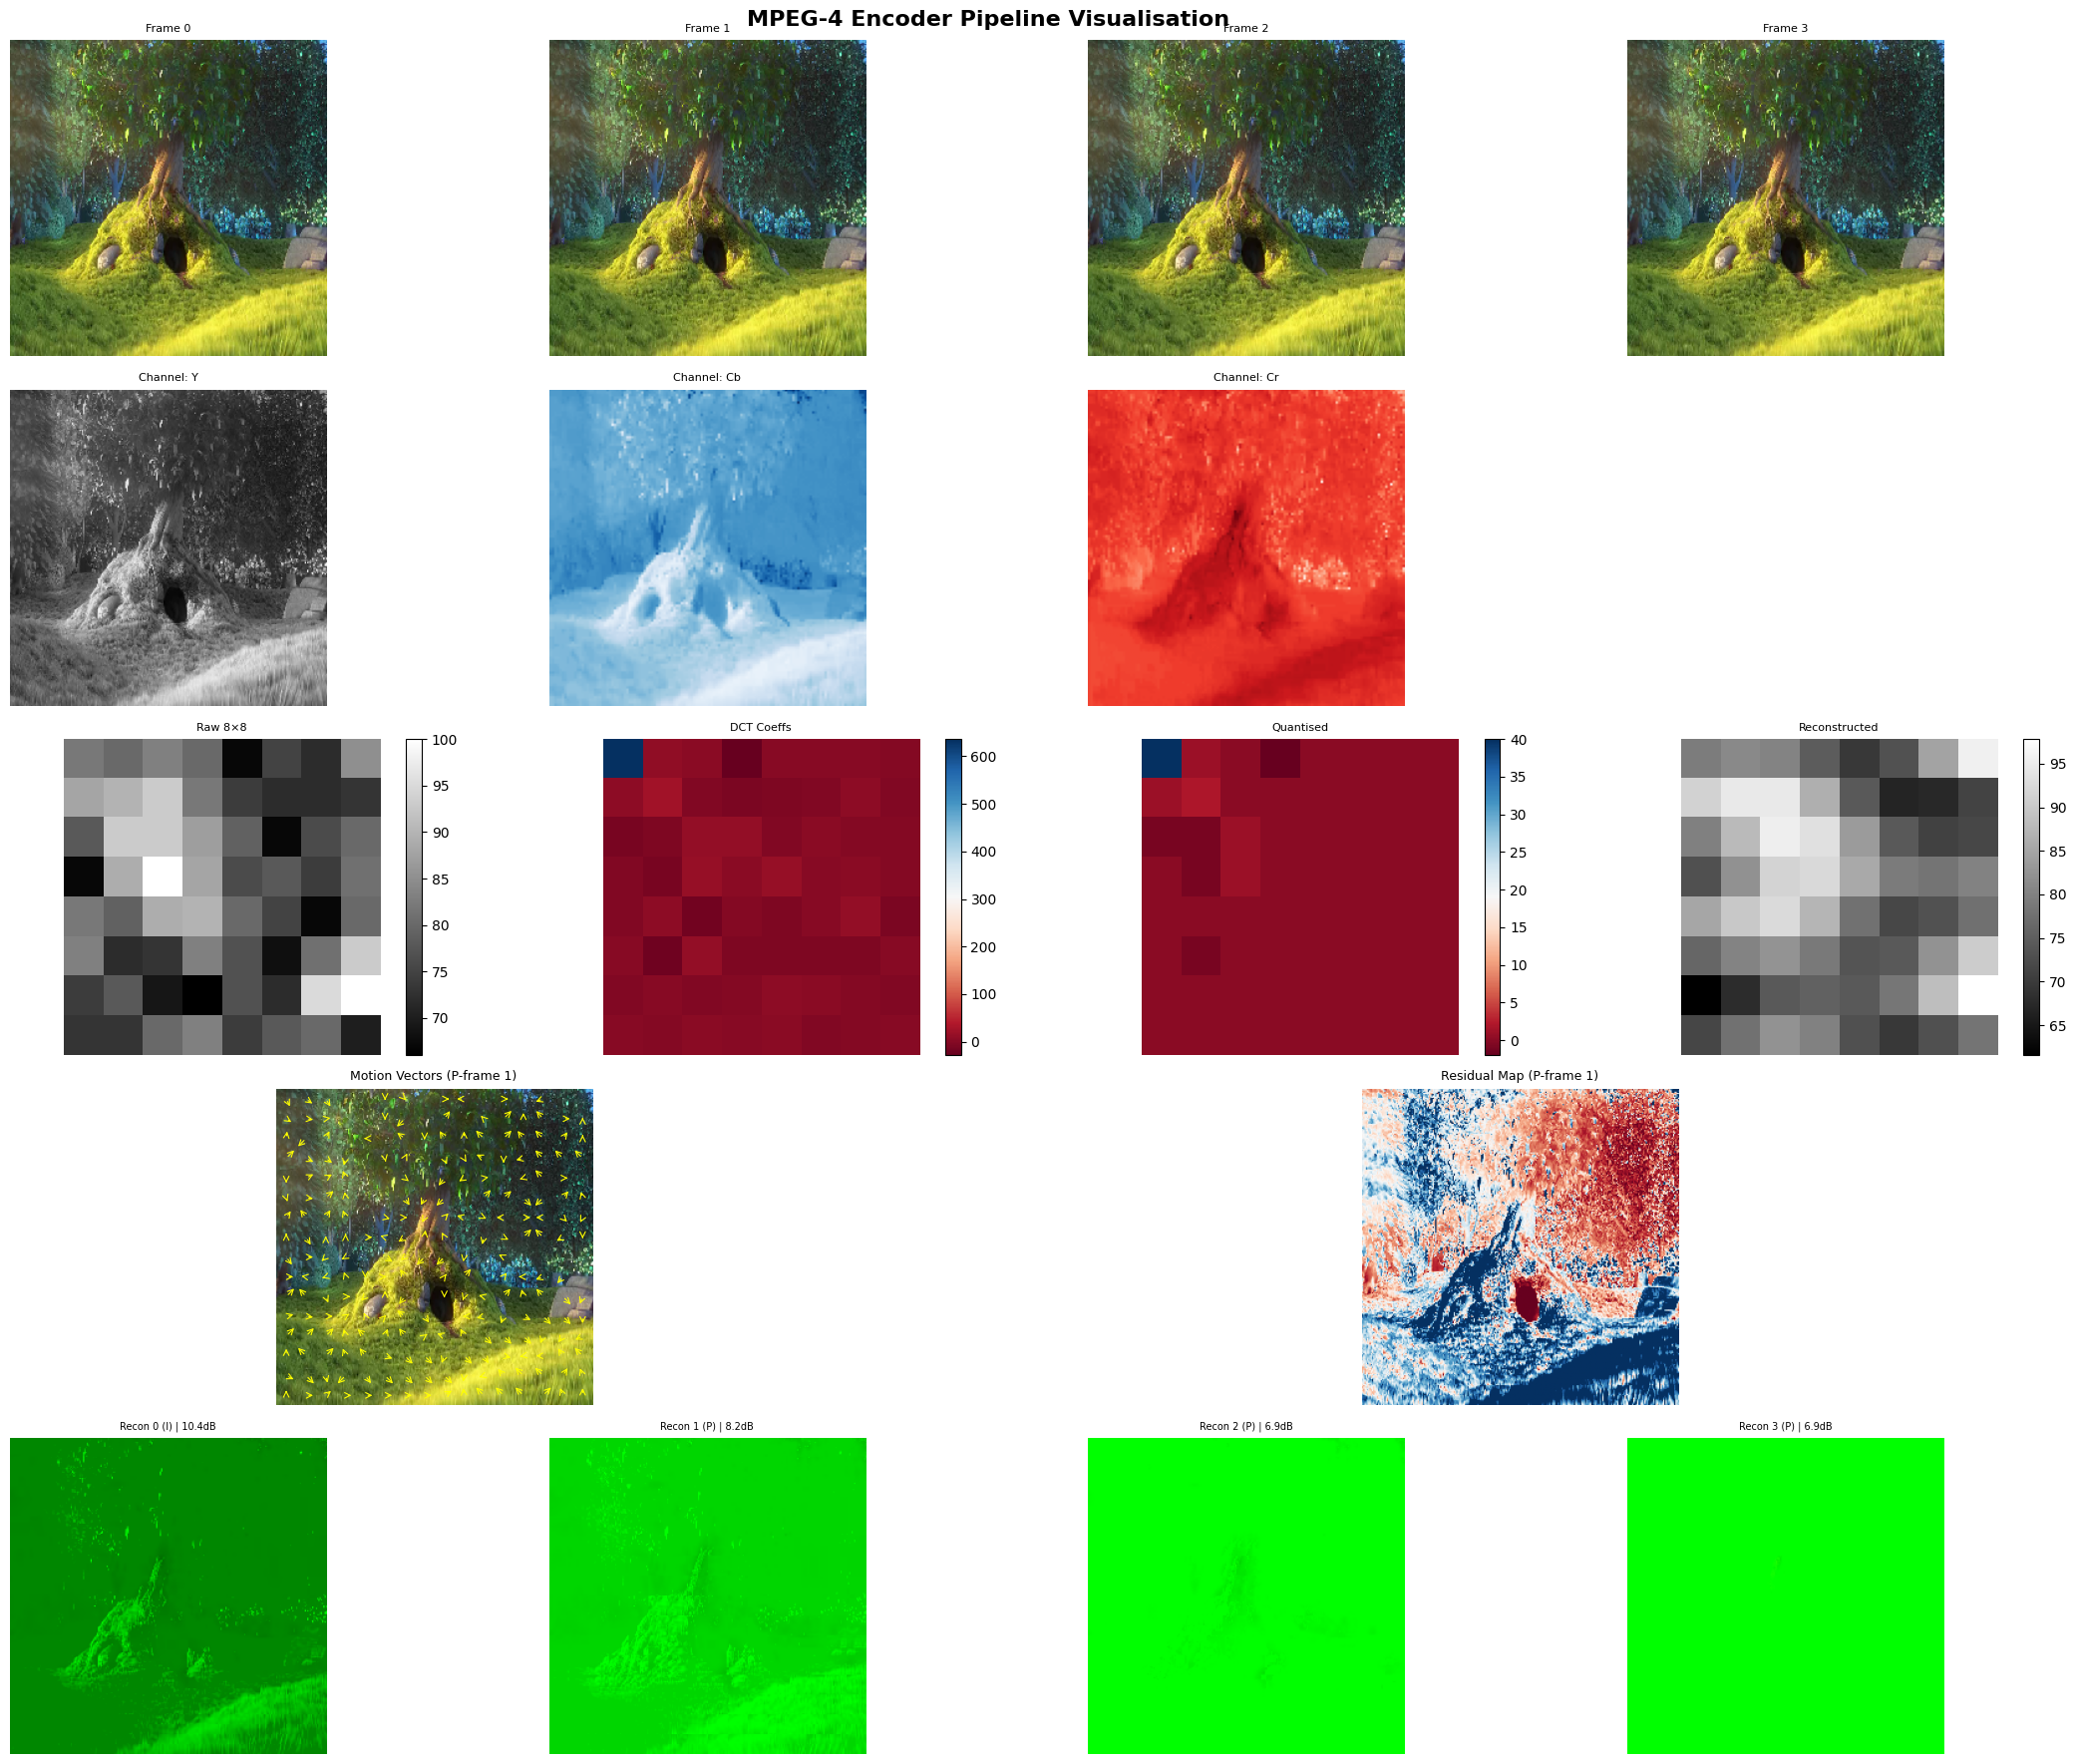

Figure saved as pipeline_visualisation.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(22, 18))
fig.suptitle("MPEG-4 Encoder Pipeline Visualisation", fontsize=16, fontweight='bold')


n_show = min(4, len(raw_frames))
for i in range(n_show):
    ax = fig.add_subplot(5, n_show, i + 1)
    ax.imshow(cv2.cvtColor(raw_frames[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {i}", fontsize=8)
    ax.axis('off')

Y0, Cb0, Cr0 = bgr_to_ycbcr(raw_frames[0])
for j, (ch, name, cmap) in enumerate([(Y0,'Y','gray'),(Cb0,'Cb','Blues'),(Cr0,'Cr','Reds')]):
    ax = fig.add_subplot(5, 4, 4 + j + 1)
    ax.imshow(ch, cmap=cmap)
    ax.set_title(f"Channel: {name}", fontsize=8)
    ax.axis('off')


block_raw = Y0[8:16, 8:16]
block_dct = dct2(block_raw)
block_q   = quantise(block_dct, Q_MATRIX[:8,:8])
block_rec = idct2(dequantise(block_q, Q_MATRIX[:8,:8]))

for j, (data, title, cmap) in enumerate([
    (block_raw,  "Raw 8×8",       'gray'),
    (block_dct,  "DCT Coeffs",    'RdBu'),
    (block_q,    "Quantised",     'RdBu'),
    (block_rec,  "Reconstructed", 'gray'),
]):
    ax = fig.add_subplot(5, 4, 8 + j + 1)
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.axis('off')


ax_mv = fig.add_subplot(5, 2, 7)

pdata = encode_pframe(raw_frames[1], recon_frames[0], Q_MATRIX, search_win=SEARCH_WIN)
ax_mv.imshow(cv2.cvtColor(raw_frames[1], cv2.COLOR_BGR2RGB))
for (r, c, dr, dc) in pdata['mvs']:
    ax_mv.annotate("", xy=(c+dc+8, r+dr+8), xytext=(c+8, r+8),
                   arrowprops=dict(arrowstyle="->", color='yellow', lw=0.8))
ax_mv.set_title("Motion Vectors (P-frame 1)", fontsize=9)
ax_mv.axis('off')


ax_res = fig.add_subplot(5, 2, 8)
ax_res.imshow(pdata['residual_map'], cmap='RdBu',
              vmin=-50, vmax=50)
ax_res.set_title("Residual Map (P-frame 1)", fontsize=9)
ax_res.axis('off')

for i in range(min(4, len(recon_frames))):
    ax = fig.add_subplot(5, n_show, 16 + i + 1)
    ax.imshow(cv2.cvtColor(recon_frames[i], cv2.COLOR_BGR2RGB))
    ftype = "I" if i % GOP_SIZE == 0 else "P"
    ax.set_title(f"Recon {i} ({ftype}) | {psnr_values[i]:.1f}dB", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig("pipeline_visualisation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as pipeline_visualisation.png")

  Frame 000 → I-frame
  Frame 001 → P-frame
  Frame 002 → P-frame
  Frame 003 → P-frame
  Frame 004 → I-frame
  Frame 005 → P-frame
  Frame 006 → P-frame
  Frame 007 → P-frame
  Frame 008 → I-frame
  Frame 009 → P-frame
  Frame 010 → P-frame
  Frame 011 → P-frame
  Frame 012 → I-frame
  Frame 013 → P-frame
  Frame 014 → P-frame
  Frame 015 → P-frame
  Frame 016 → I-frame
  Frame 017 → P-frame
  Frame 018 → P-frame
  Frame 019 → P-frame
  Frame 020 → I-frame
  Frame 021 → P-frame
  Frame 022 → P-frame
  Frame 023 → P-frame
  Frame 024 → I-frame
  Frame 025 → P-frame
  Frame 026 → P-frame
  Frame 027 → P-frame
  Frame 028 → I-frame
  Frame 029 → P-frame

 Encoded 30 frames → tmp_q2.bin
   Original : 5,898,240 bytes
   Compressed: 1,592,536 bytes
   Compression ratio: 3.70x
  Frame 000 → I-frame
  Frame 001 → P-frame
  Frame 002 → P-frame
  Frame 003 → P-frame
  Frame 004 → I-frame
  Frame 005 → P-frame
  Frame 006 → P-frame
  Frame 007 → P-frame
  Frame 008 → I-frame
  Frame 009 → P-fram

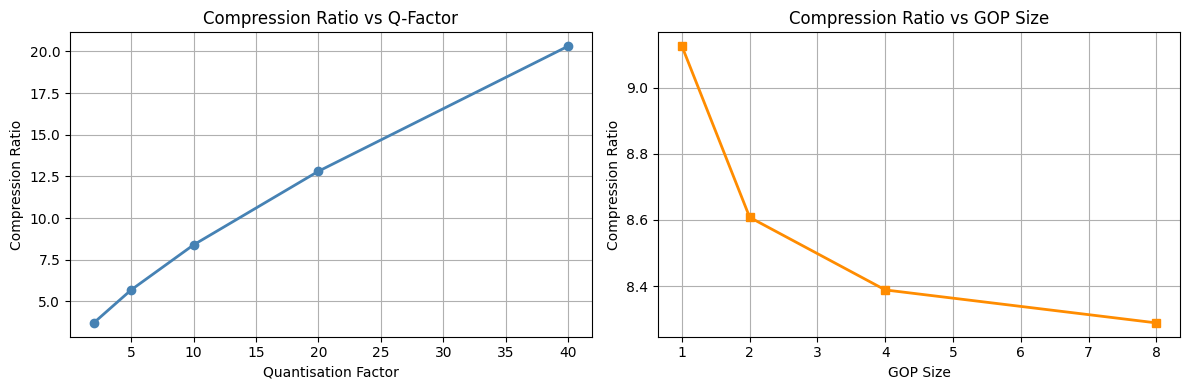

Report plots saved


In [12]:

q_factors = [2, 5, 10, 20, 40]
ratios_q  = []
for qf in q_factors:
    qm = Q_MATRIX * (qf / Q_FACTOR)
    _, r = encode_video(raw_frames, f"tmp_q{qf}.bin", qm, gop=GOP_SIZE, search_win=4)
    ratios_q.append(r)

gop_sizes = [1, 2, 4, 8]
ratios_g  = []
for g in gop_sizes:
    _, r = encode_video(raw_frames, f"tmp_g{g}.bin", Q_MATRIX, gop=g, search_win=4)
    ratios_g.append(r)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(q_factors, ratios_q, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel("Quantisation Factor")
ax1.set_ylabel("Compression Ratio")
ax1.set_title("Compression Ratio vs Q-Factor")
ax1.grid(True)

ax2.plot(gop_sizes, ratios_g, 's-', color='darkorange', linewidth=2)
ax2.set_xlabel("GOP Size")
ax2.set_ylabel("Compression Ratio")
ax2.set_title("Compression Ratio vs GOP Size")
ax2.grid(True)

plt.tight_layout()
plt.savefig("report_plots.png", dpi=150)
plt.show()
print("Report plots saved")